In [36]:
#1.Imports + 基础工具
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("torch:", torch.__version__)

torch: 2.7.1+cu118


In [37]:
#2.CFG + 固定随机种子 + device
from dataclasses import dataclass

@dataclass
class CFG:
    seed: int = 42
    img_size: int = 256
    batch_size: int = 4
    num_workers: int = 4
    lr: float = 1e-3
    epochs: int = 20
    val_ratio: float = 0.2
    test_ratio: float = 0.1
    keep_negative_ratio: float = 0.5  # 训练时保留多少“全黑mask”的负样本

cfg = CFG()

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(cfg)

cuda
CFG(seed=42, img_size=256, batch_size=4, num_workers=4, lr=0.001, epochs=20, val_ratio=0.2, test_ratio=0.1, keep_negative_ratio=0.5)


In [38]:
import os, torch

# 1) 让 CUDA 同步报错位置（定位更准，慢一点但更稳）
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# 2) 减少 cuDNN 选算法引发的偶发崩溃
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# 3) 先不开 TF32（有时能规避数值不稳定）
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

# 4) 清空缓存
torch.cuda.empty_cache()
print("✅ stability switches set")

✅ stability switches set


In [39]:
#3.数据路径 + 扫描病人列表（按病人切分，避免数据泄漏）
data_dir = "/root/autodl-tmp/data/lgg-mri-segmentation/3m"  
assert os.path.exists(data_dir), f"data_dir not found: {data_dir}"

# 病人目录通常是 TCGA_...
patient_dirs = sorted([d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)])
print("Num patients:", len(patient_dirs))
print("Example patient:", os.path.basename(patient_dirs[0]) if patient_dirs else "N/A")

Num patients: 110
Example patient: TCGA_CS_4941_19960909


In [40]:
!pip install opencv-python

1273.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [41]:
#4.Dataset
import cv2

def read_rgb(path, img_size):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"Failed to read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2,0,1))  # [3,H,W]
    return img

def read_mask(path, img_size):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise RuntimeError(f"Failed to read mask: {path}")
    m = cv2.resize(m, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    m = (m > 0).astype(np.float32)     # 0/1
    m = m[None, ...]                   # [1,H,W]
    return m

def list_patient_pairs(patient_dir):
    # 常见后缀 tif / png / jpg，mask里含 _mask
    masks = []
    for ext in ["tif", "tiff", "png", "jpg", "jpeg"]:
        masks += glob.glob(os.path.join(patient_dir, f"*mask*.{ext}"))
        masks += glob.glob(os.path.join(patient_dir, f"*mask*.{ext.upper()}"))
    masks = sorted(set(masks))

    pairs = []
    for mp in masks:
        # 从 mask 推 image 名：去掉 _mask
        # 兼容：xxx_mask.tif / xxx_mask.png
        imgp = mp.replace("_mask", "")
        if os.path.exists(imgp):
            pairs.append((imgp, mp))
        else:
            # 有些数据是 mask_xxx 形式
            base = os.path.basename(mp)
            if base.startswith("mask_"):
                imgp2 = os.path.join(os.path.dirname(mp), base.replace("mask_", ""))
                if os.path.exists(imgp2):
                    pairs.append((imgp2, mp))
    return pairs

class LGGDataset(Dataset):
    def __init__(self, patient_dirs, img_size=256, keep_negative_ratio=1.0, is_train=True):
        self.img_size = img_size
        self.keep_negative_ratio = keep_negative_ratio
        self.is_train = is_train

        # 收集所有 (img,mask)
        pairs = []
        for pd in patient_dirs:
            pairs += list_patient_pairs(pd)

        if len(pairs) == 0:
            raise RuntimeError("No (image, mask) pairs found. 请检查数据集文件名是否包含 _mask。")

        # 统计正负（mask 是否有肿瘤）
        pos, neg = [], []
        for imgp, mp in pairs:
            m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            if m is None:
                continue
            if (m > 0).any():
                pos.append((imgp, mp))
            else:
                neg.append((imgp, mp))

        # 训练集可下采样负样本（避免全黑 slice 太多）
        if is_train and keep_negative_ratio < 1.0:
            k = int(len(neg) * keep_negative_ratio)
            k = max(0, min(k, len(neg)))

            if k > 0:
                rng = np.random.RandomState(cfg.seed)
                idx = rng.choice(len(neg), size=k, replace=False)
                neg = [neg[i] for i in idx]
            else:
                neg = []
        
        self.pairs = pos + neg
        random.shuffle(self.pairs)

        self.pos_count = len(pos)
        self.neg_count = len(neg)
        self.total_count = len(self.pairs)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        imgp, mp = self.pairs[idx]
        img = read_rgb(imgp, self.img_size)
        mask = read_mask(mp, self.img_size)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [42]:
#5.按病人划分 train/val/test + 构建 DataLoader
# 按病人划分，避免同一病人的切片出现在 train 和 val/test 里
rng = np.random.RandomState(cfg.seed)
perm = rng.permutation(len(patient_dirs)).tolist()

n = len(patient_dirs)
n_val  = int(n * cfg.val_ratio)
n_test = int(n * cfg.test_ratio)
n_train = n - n_val - n_test

train_patients = [patient_dirs[i] for i in perm[:n_train]]
val_patients   = [patient_dirs[i] for i in perm[n_train:n_train+n_val]]
test_patients  = [patient_dirs[i] for i in perm[n_train+n_val:]]

print("train:", len(train_patients), "val:", len(val_patients), "test:", len(test_patients))
print("Example train patient:", os.path.basename(train_patients[0]))

train_ds = LGGDataset(train_patients, img_size=cfg.img_size, keep_negative_ratio=cfg.keep_negative_ratio, is_train=True)
val_ds   = LGGDataset(val_patients,   img_size=cfg.img_size, keep_negative_ratio=1.0, is_train=False)
test_ds  = LGGDataset(test_patients,  img_size=cfg.img_size, keep_negative_ratio=1.0, is_train=False)

print("train slices:", len(train_ds), "val slices:", len(val_ds), "test slices:", len(test_ds))
print("train pos/neg:", train_ds.pos_count, train_ds.neg_count)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

print("✅ train_loader batches:", len(train_loader))

train: 77 val: 22 test: 11
Example train patient: TCGA_HT_7602_19951103
train slices: 1877 val slices: 778 test slices: 391
train pos/neg: 994 883
✅ train_loader batches: 469


img: torch.Size([3, 256, 256]) 0.0 0.8509804010391235
mask: torch.Size([1, 256, 256]) tensor([0., 1.])


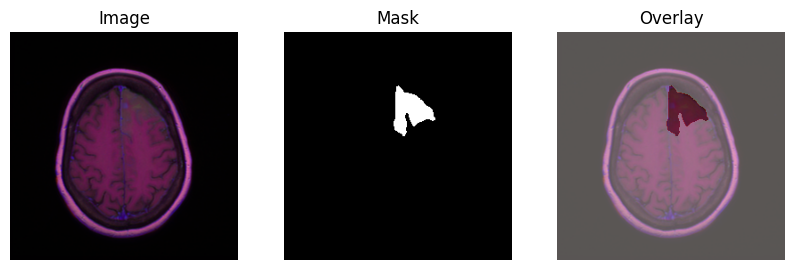

In [43]:
#6.可视化检查
img, mask = train_ds[0]
print("img:", img.shape, img.min().item(), img.max().item())
print("mask:", mask.shape, mask.unique())

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.imshow(img.permute(1,2,0)); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask[0], cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(img.permute(1,2,0)); plt.imshow(mask[0], alpha=0.35, cmap="Reds"); plt.title("Overlay"); plt.axis("off")
plt.show()

In [44]:
#7.model UNet + ASPP + Top-Down FPN + 多尺度监督
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )
    def forward(self, x): return self.net(x)

class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(1,2,4)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)),
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=rates[0], dilation=rates[0], bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)),
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=rates[1], dilation=rates[1], bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)),
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=rates[2], dilation=rates[2], bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)),
        ])
        self.project = nn.Sequential(
            nn.Conv2d(out_ch*4, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        xs = [b(x) for b in self.branches]
        return self.project(torch.cat(xs, dim=1))

class FPNTopDown(nn.Module):
    def __init__(self, c2_ch, c3_ch, c4_ch, fpn_ch=128):
        super().__init__()
        self.lat2 = nn.Conv2d(c2_ch, fpn_ch, 1)
        self.lat3 = nn.Conv2d(c3_ch, fpn_ch, 1)
        self.lat4 = nn.Conv2d(c4_ch, fpn_ch, 1)
        self.s2 = nn.Conv2d(fpn_ch, fpn_ch, 3, padding=1)
        self.s3 = nn.Conv2d(fpn_ch, fpn_ch, 3, padding=1)
        self.s4 = nn.Conv2d(fpn_ch, fpn_ch, 3, padding=1)
    def forward(self, c2, c3, c4):
        p4 = self.lat4(c4)
        p3 = self.lat3(c3) + F.interpolate(p4, size=c3.shape[-2:], mode="bilinear", align_corners=False)
        p2 = self.lat2(c2) + F.interpolate(p3, size=c2.shape[-2:], mode="bilinear", align_corners=False)
        return self.s2(p2), self.s3(p3), self.s4(p4)

class SegHead(nn.Module):
    def __init__(self, in_ch, mid_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, 1, 1)
        )
    def forward(self, x): return self.net(x)

class UNetASPP_TopDownFPN_DS(nn.Module):
    def __init__(self, in_ch=3, base=32, fpn_ch=128):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)     # 256
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base*2)    # 128 (C2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base*2, base*4)  # 64  (C3)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(base*4, base*8)  # 32  (C4)

        self.aspp = ASPP(base*8, base*8)
        self.fpn = FPNTopDown(base*2, base*4, base*8, fpn_ch=fpn_ch)

        self.head_p2 = SegHead(fpn_ch)
        self.head_p3 = SegHead(fpn_ch)
        self.head_p4 = SegHead(fpn_ch)

        self.fuse = nn.Sequential(
            nn.Conv2d(fpn_ch*3, fpn_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(fpn_ch),
            nn.ReLU(inplace=True),
        )
        self.head_final = SegHead(fpn_ch)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.aspp(e4)

        p2, p3, p4 = self.fpn(e2, e3, b)
        logits_p2 = self.head_p2(p2)  # 128
        logits_p3 = self.head_p3(p3)  # 64
        logits_p4 = self.head_p4(p4)  # 32

        p3u = F.interpolate(p3, size=p2.shape[-2:], mode="bilinear", align_corners=False)
        p4u = F.interpolate(p4, size=p2.shape[-2:], mode="bilinear", align_corners=False)
        fused = self.fuse(torch.cat([p2, p3u, p4u], dim=1))
        fused256 = F.interpolate(fused, scale_factor=2, mode="bilinear", align_corners=False)
        logits_final = self.head_final(fused256)  # 256

        return logits_final, logits_p2, logits_p3, logits_p4

model = UNetASPP_TopDownFPN_DS(in_ch=3, base=32, fpn_ch=128).to(device)
print("Model:", model.__class__.__name__)

Model: UNetASPP_TopDownFPN_DS


In [45]:
#8.Loss（多尺度监督）+ Dice/IoU 指标
bce = nn.BCEWithLogitsLoss()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
        dice = (2*inter + self.eps) / (union + self.eps)
        return 1 - dice.mean()

dice_loss = DiceLoss()

def loss_bce_dice(logits, targets):
    return 0.5*bce(logits, targets) + 0.5*dice_loss(logits, targets)

def total_loss_multiscale(outputs, masks, w_final=1.0, w_p2=0.5, w_p3=0.25, w_p4=0.125):
    logits_final, logits_p2, logits_p3, logits_p4 = outputs
    gt_p2 = F.interpolate(masks, size=logits_p2.shape[-2:], mode="nearest")
    gt_p3 = F.interpolate(masks, size=logits_p3.shape[-2:], mode="nearest")
    gt_p4 = F.interpolate(masks, size=logits_p4.shape[-2:], mode="nearest")
    l_final = loss_bce_dice(logits_final, masks)
    l_p2 = loss_bce_dice(logits_p2, gt_p2)
    l_p3 = loss_bce_dice(logits_p3, gt_p3)
    l_p4 = loss_bce_dice(logits_p4, gt_p4)
    total = w_final*l_final + w_p2*l_p2 + w_p3*l_p3 + w_p4*l_p4
    return total

@torch.no_grad()
def dice_iou_from_logits(logits, targets, thr=0.5, eps=1e-7):
    prob = torch.sigmoid(logits)
    pred = (prob > thr).float()
    inter = (pred * targets).sum(dim=(2,3))
    dice = (2*inter + eps) / (pred.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + eps)
    iou  = (inter + eps) / (pred.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - inter + eps)
    return dice.mean().item(), iou.mean().item()

In [46]:
#9.pixel-level accuracy 计算函数
@torch.no_grad()
def pixel_accuracy_from_logits(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    
    correct = (preds == masks).float().sum()
    total = torch.numel(preds)
    
    return (correct / total).item()

In [47]:
#9.Optimizer + Scheduler
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
print("Optimizer & Scheduler ready.")

Optimizer & Scheduler ready.


In [48]:
#10.Train / Validate 循环 + 保存最好模型
from tqdm import tqdm

@torch.no_grad()
def validate(model, loader):
    model.eval()
    losses, dices, ious, accs = [], [], [], []

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = total_loss_multiscale(outputs, masks)

        logits_final = outputs[0]

        dice, iou = dice_iou_from_logits(logits_final, masks)
        acc = pixel_accuracy_from_logits(logits_final, masks)

        losses.append(loss.item())
        dices.append(dice)
        ious.append(iou)
        accs.append(acc)

    return (
        float(np.mean(losses)),
        float(np.mean(dices)),
        float(np.mean(ious)),
        float(np.mean(accs))
    )

def train_one_epoch(model, loader):
    model.train()
    losses = []
    for imgs, masks in tqdm(loader, leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = total_loss_multiscale(outputs, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

best_val_dice = -1.0
history = []

for epoch in range(1, cfg.epochs+1):

    tr_loss = train_one_epoch(model, train_loader)
    val_loss, val_dice, val_iou, val_acc = validate(model, val_loader)

    scheduler.step()

    history.append((epoch, tr_loss, val_loss, val_dice, val_iou, val_acc))

    print(f"Epoch {epoch:02d} | "
          f"train_loss {tr_loss:.4f} | "
          f"val_loss {val_loss:.4f} | "
          f"dice {val_dice:.4f} | "
          f"iou {val_iou:.4f} | "
          f"acc {val_acc:.4f}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_model.pt")
        print("  ✅ saved best model")

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | train_loss 0.8149 | val_loss 0.8186 | dice 0.6109 | iou 0.5782 | acc 0.9887
  ✅ saved best model


Epoch 02 | train_loss 0.6897 | val_loss 0.8042 | dice 0.5772 | iou 0.5462 | acc 0.9879


Epoch 03 | train_loss 0.6710 | val_loss 0.8389 | dice 0.3829 | iou 0.3469 | acc 0.9751


Epoch 04 | train_loss 0.6473 | val_loss 0.8350 | dice 0.4129 | iou 0.3728 | acc 0.9725


...

Epoch 17 | train_loss 0.5339 | val_loss 0.7374 | dice 0.7358 | iou 0.7040 | acc 0.9957


Epoch 18 | train_loss 0.5323 | val_loss 0.7387 | dice 0.7400 | iou 0.7078 | acc 0.9958


  0%|          | 2/469 [00:00<01:57,  3.99it/s]1837.24s - thread._ident is None in _get_related_thread!


Epoch 19 | train_loss 0.5302 | val_loss 0.7379 | dice 0.7411 | iou 0.7091 | acc 0.9959


Epoch 20 | train_loss 0.5311 | val_loss 0.7381 | dice 0.7504 | iou 0.7183 | acc 0.9960


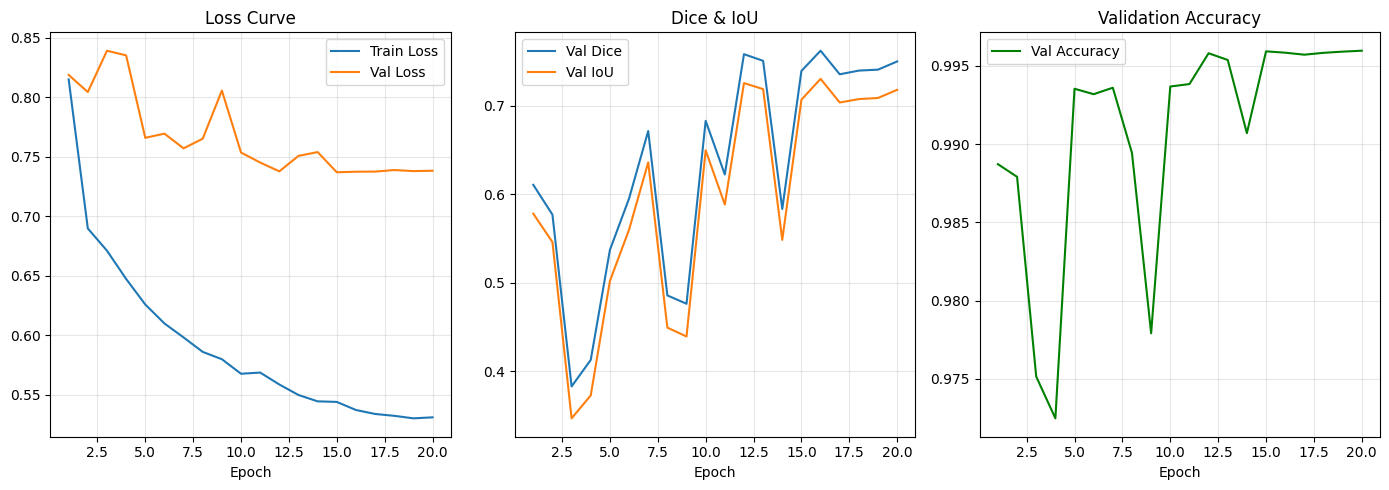

In [ ]:
#11.训练曲线
import matplotlib.pyplot as plt

epochs     = [h[0] for h in history]
train_loss = [h[1] for h in history]
val_loss   = [h[2] for h in history]
val_dice   = [h[3] for h in history]
val_iou    = [h[4] for h in history]
val_acc    = [h[5] for h in history]

plt.figure(figsize=(12,8))

# Loss
plt.subplot(2,2,1)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

# Dice
plt.subplot(2,2,2)
plt.plot(epochs, val_dice)
plt.title("Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid(alpha=0.3)

# IoU
plt.subplot(2,2,3)
plt.plot(epochs, val_iou)
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(alpha=0.3)

# Accuracy
plt.subplot(2,2,4)
plt.plot(epochs, val_acc)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TEST | loss 0.7573 | dice 0.8295 | iou 0.8001 | acc 0.9970
Positive samples in test_ds: 111 / 391


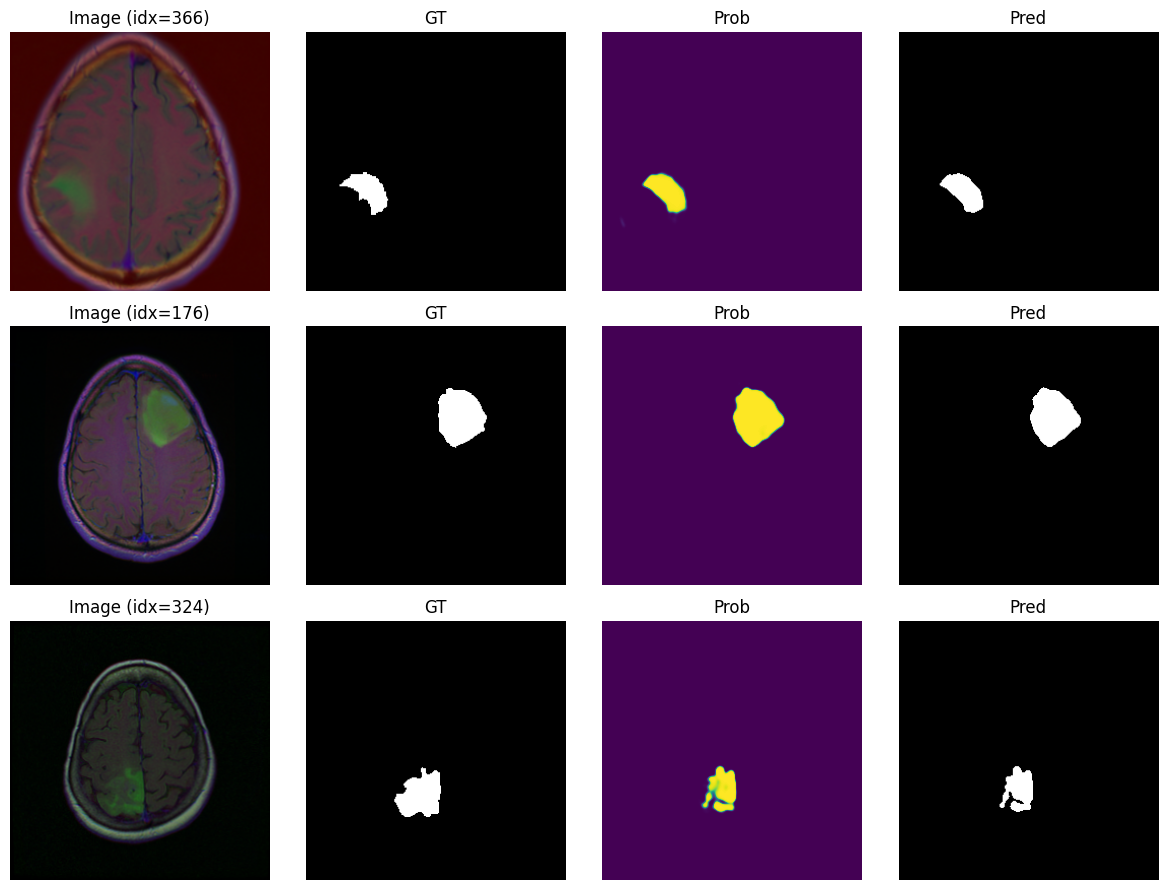

In [51]:
# 12. Test 指标 + 可视化（优先抽有肿瘤的样本）
@torch.no_grad()
def predict_prob_pred(model, img, thr=0.5):
    model.eval()
    outputs = model(img.unsqueeze(0).to(device))
    logits = outputs[0]
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred = (prob > thr).astype(np.uint8)
    return prob, pred

def build_positive_indices(ds, max_scan=None):
    """
    返回 ds 中 mask 非全0 的样本索引列表
    max_scan: 为了速度，可限制最多扫描多少个样本（None 表示全扫）
    """
    idxs = []
    n = len(ds) if max_scan is None else min(len(ds), max_scan)
    for i in range(n):
        _, mask = ds[i]
        # mask: [1,H,W]
        if mask.sum().item() > 0:
            idxs.append(i)
    return idxs

# --- test eval ---
model.load_state_dict(torch.load("best_unet_fpn_ds.pt", map_location=device))
test_loss, test_dice, test_iou, test_acc = validate(model, test_loader)
print(f"TEST | loss {test_loss:.4f} | dice {test_dice:.4f} | iou {test_iou:.4f} | acc {test_acc:.4f}")
# --- build positive pool (只做一次即可；如果太慢可设置 max_scan=500) ---
pos_idxs = build_positive_indices(test_ds, max_scan=None)
print(f"Positive samples in test_ds: {len(pos_idxs)} / {len(test_ds)}")

# --- visualize ---
model.to(device).eval()
n_show = 3
thr = 0.5

plt.figure(figsize=(12, 3*n_show))

for i in range(n_show):
    if len(pos_idxs) > 0:
        idx = int(np.random.choice(pos_idxs))
    else:
        idx = int(np.random.randint(len(test_ds)))

    img, mask = test_ds[idx]
    prob, pred = predict_prob_pred(model, img, thr=thr)

    img_np = img.permute(1,2,0).numpy()
    gt = mask[0].numpy()

    plt.subplot(n_show, 4, i*4+1); plt.imshow(img_np); plt.title(f"Image (idx={idx})"); plt.axis("off")
    plt.subplot(n_show, 4, i*4+2); plt.imshow(gt, cmap="gray"); plt.title("GT"); plt.axis("off")
    plt.subplot(n_show, 4, i*4+3); plt.imshow(prob); plt.title("Prob"); plt.axis("off")
    plt.subplot(n_show, 4, i*4+4); plt.imshow(pred, cmap="gray"); plt.title("Pred"); plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
import torch
import numpy as np

@torch.no_grad()
def compute_confusion_matrix(model, loader, threshold=0.5):
    model.eval()

    TP = FP = FN = TN = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        logits = outputs[0]

        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        TP += torch.sum((preds == 1) & (masks == 1)).item()
        TN += torch.sum((preds == 0) & (masks == 0)).item()
        FP += torch.sum((preds == 1) & (masks == 0)).item()
        FN += torch.sum((preds == 0) & (masks == 1)).item()

    return TP, FP, FN, TN

In [53]:
TP, FP, FN, TN = compute_confusion_matrix(model, test_loader)

precision = TP / (TP + FP + 1e-7)
recall    = TP / (TP + FN + 1e-7)
specificity = TN / (TN + FP + 1e-7)
f1 = 2 * precision * recall / (precision + recall + 1e-7)

print("Confusion Matrix:")
print(f"TP: {TP:.0f}  FP: {FP:.0f}")
print(f"FN: {FN:.0f}  TN: {TN:.0f}")
print("\nMetrics:")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")

Confusion Matrix:
TP: 140726  FP: 33075
FN: 43590  TN: 25407185

Metrics:
Precision   : 0.8097
Recall      : 0.7635
Specificity : 0.9987
F1-score    : 0.7859


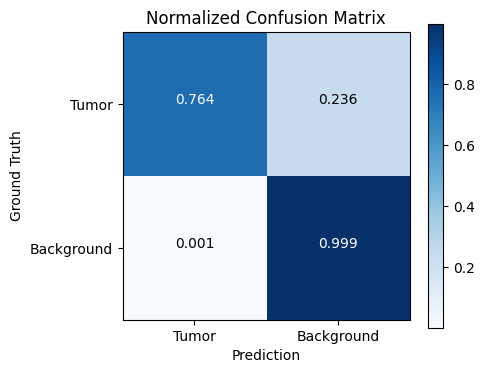

In [54]:
#14.绘制混淆矩阵
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[TP, FN],
               [FP, TN]], dtype=float)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))
plt.imshow(cm_norm, cmap="Blues")
plt.colorbar()

labels = ["Tumor", "Background"]

plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_norm[i,j]:.3f}",
                 ha="center",
                 color="white" if cm_norm[i,j] > 0.5 else "black")

plt.title("Normalized Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()